In [1]:
import pandas as pd
from IPython.display import Markdown
from matplotlib import pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
# @title Reading the data
df = pd.read_excel('data/Telco_customer_churn.xlsx')

# Fix: drop needs to be redistributed
df = df.drop(columns="Count")
print('Count dropped ✓')

df_dict = pd.DataFrame([
    {
        "variable": "CustomerID",
        "description": "Unique identifier for each customer",
        "type": "Qualitative",
        "subtype": "Nominal",
    },
    {
        "variable": "Country",
        "description": "Country of the customer's residence",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "State",
        "description": "State of the customer's residence",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "City",
        "description": "City of the customer's residence",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Zip Code",
        "description": "Zip code of the customer's residence",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Lat Long",
        "description": "Combined latitude and longitude coordinates",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Latitude",
        "description": "Latitude of the customer's location",
        "type": "Quantitative",
        "subtype": "Continuous"
    },
    {
        "variable": "Longitude",
        "description": "Longitude of the customer's location",
        "type": "Quantitative",
        "subtype": "Continuous"
    },
    {
        "variable": "Gender",
        "description": "Customer's gender (Male/Female)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Senior Citizen",
        "description": "Indicates if the customer is 65 or older (Yes, No)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Partner",
        "description": "Whether the customer has a partner (Yes, No)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Dependents",
        "description": "Whether the customer has dependents (Yes, No)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Tenure Months",
        "description": "Number of months the customer has stayed with the company",
        "type": "Quantitative",
        "subtype": "Discrete"
    },
    {
        "variable": "Phone Service",
        "description": "Whether the customer has a phone service (Yes, No)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Multiple Lines",
        "description": "Whether the customer has multiple lines (Yes, No, No phone service)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Internet Service",
        "description": "Customer’s internet service provider (DSL, Fiber optic, No)",
        "type": "Qualitative",
        "subtype": "Ordinal"
    },
    {
        "variable": "Online Security",
        "description": "Whether the customer has online security (Yes, No, No internet service)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Online Backup",
        "description": "Whether the customer has online backup (Yes, No, No internet service)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Device Protection",
        "description": "Whether the customer has device protection (Yes, No, No internet service)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Tech Support",
        "description": "Whether the customer has tech support (Yes, No, No internet service)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Streaming TV",
        "description": "Whether the customer has streaming TV (Yes, No, No internet service)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Streaming Movies",
        "description": "Whether the customer has streaming movies (Yes, No, No internet service)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Contract",
        "description": "The contract term of the customer (Month-to-month, One year, Two year)",
        "type": "Qualitative",
        "subtype": "Ordinal"
    },
    {
        "variable": "Paperless Billing",
        "description": "Whether the customer has paperless billing (Yes, No)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Payment Method",
        "description": "The customer’s payment method",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Monthly Charges",
        "description": "The amount charged to the customer monthly",
        "type": "Quantitative",
        "subtype": "Continuous"
    },
    {
        "variable": "Total Charges",
        "description": "The total amount charged to the customer",
        "type": "Quantitative",
        "subtype": "Continuous"
    },
    {
        "variable": "Churn Label",
        "description": "Indicates if the customer left within the last month (Yes, No)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Churn Value",
        "description": "Binary representation of churn (1 for Churn, 0 for No Churn)",
        "type": "Qualitative",
        "subtype": "Nominal"
    },
    {
        "variable": "Churn Score",
        "description": "A value from 0-100 that predicts the likelihood of churn",
        "type": "Quantitative",
        "subtype": "Discrete"
    },
    {
        "variable": "CLTV",
        "description": "Customer Lifetime Value (predicted net profit from the customer)",
        "type": "Quantitative",
        "subtype": "Continuous"
    },
    {
        "variable": "Churn Reason",
        "description": "Specific reason why the customer left the company",
        "type": "Qualitative",
        "subtype": "Nominal"
    }
])
df_dict

Count dropped ✓


,variable,description,type,subtype
0,CustomerID,Unique identifier for each customer,Qualitative,Nominal
1,Country,Country of the customer's residence,Qualitative,Nominal
2,State,State of the customer's residence,Qualitative,Nominal
3,City,City of the customer's residence,Qualitative,Nominal
4,Zip Code,Zip code of the customer's residence,Qualitative,Nominal
5,Lat Long,Combined latitude and longitude coordinates,Qualitative,Nominal
6,Latitude,Latitude of the customer's location,Quantitative,Continuous
7,Longitude,Longitude of the customer's location,Quantitative,Continuous
8,Gender,Customer's gender (Male/Female),Qualitative,Nominal
9,Senior Citizen,"Indicates if the customer is 65 or older (Yes,...",Qualitative,Nominal


In [3]:
# @title Initial Informations
display(Markdown("### First Lines"))
display(df.head())

display(Markdown("### Last Lines"))
display(df.tail())

display(Markdown("### Variables Information"))
df.info()

display(Markdown("### Quantity of Unique Values"))
df.nunique()

### First Lines

,CustomerID,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


### Last Lines

,CustomerID,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,No,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


### Variables Information

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Country            7043 non-null   str    
 2   State              7043 non-null   str    
 3   City               7043 non-null   str    
 4   Zip Code           7043 non-null   int64  
 5   Lat Long           7043 non-null   str    
 6   Latitude           7043 non-null   float64
 7   Longitude          7043 non-null   float64
 8   Gender             7043 non-null   str    
 9   Senior Citizen     7043 non-null   str    
 10  Partner            7043 non-null   str    
 11  Dependents         7043 non-null   str    
 12  Tenure Months      7043 non-null   int64  
 13  Phone Service      7043 non-null   str    
 14  Multiple Lines     7043 non-null   str    
 15  Internet Service   7043 non-null   str    
 16  Online Security    7043 non-null   

### Quantity of Unique Values

CustomerID           7043
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

---
With this initial information:
- The dataset has 7043 entries with 33 variables
- Classification of this variables:
    - Numerical Discrete: `tenure_months`, `churn_score`
    - Numerical Continuous: `latitude`, `longitude`, `monthly_charges`, `total_charges`, `cltv`
    - Categorical Nominal: `customerid`, `country`, `state`, `city`, `zip_code`, `lat_long`, `gender`, `senior_citizen`, `partner`, `dependents`, `phone_service`, `multiple_lines`, `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, `streaming_movies`, `paperless_billing`, `payment_method`, `churn_label`, `churn_value`, `churn_reason`
    - Categorical Ordinal: `contract`, `internet_service`
---

In [4]:
display(Markdown("### Categorical Variables"))
display(df.describe(include=['object', 'string']))

### Categorical Variables

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.0,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531.0,2,20
top,3668-QPYBK,United States,California,Los Angeles,"33.964131, -118.272783",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11.0,5174,192


In [5]:
# @title Correcting assigning Total Charges to Numerical Variables
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print(f"Total Null values on Total Charges {df['Total Charges'].isnull().sum()}")

Total Null values on Total Charges 11


In [6]:
display(Markdown("### Numerical Variables"))
display(df.describe())

### Numerical Variables

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


### **Exploratory Data Analysis: Professional Insights (Univariate)**
---
#### Demographics & Profile
 - `Los Angeles` is the most represented city in the dataset.
 - The gender distribution is balanced, with **50.54%** being `Male`.
 - Only **16.21%** of clients are `Senior Citizen`.
 - The base is slightly skewed towards single people: **51.69%** are classified with `Partner: No`.
 - **76.89%** of the clients do not have `Dependents`.

#### Service Adoption and Usage
 - `Phone Service` is highly adopted(**90.31%**), with nearly half of the base (**48%**) utilizing `Multiple Lines`.
 - Value-Added Services(VAS): Adoption for support and security services (`Online Security`, `Online Backup`, `Device Protection` and `Tech Support`) fluctuates between 43%  and 49% of the total base.
 - Entertainment: Usage of streaming services (`Streaming TV` and `Streaming Movies`) is consistent at approximately 40% of the total base.
#### Billing & Contract Engagement:
 - Contract Model: A significant 55% of customers opt for Month-to-month contracts, suggesting a high potential for volatility and churn.
 - Payment Preferences: Paperless Billing is preferred by 59.2% of clients, and Electronic Check is the leading payment method (33.6%).
#### Business Target (Churn)
 - Churn Rate: The overall churn rate stands at 26.5%. One in every four customers has terminated their service, which defines the primary challenge for predictive modeling.
---

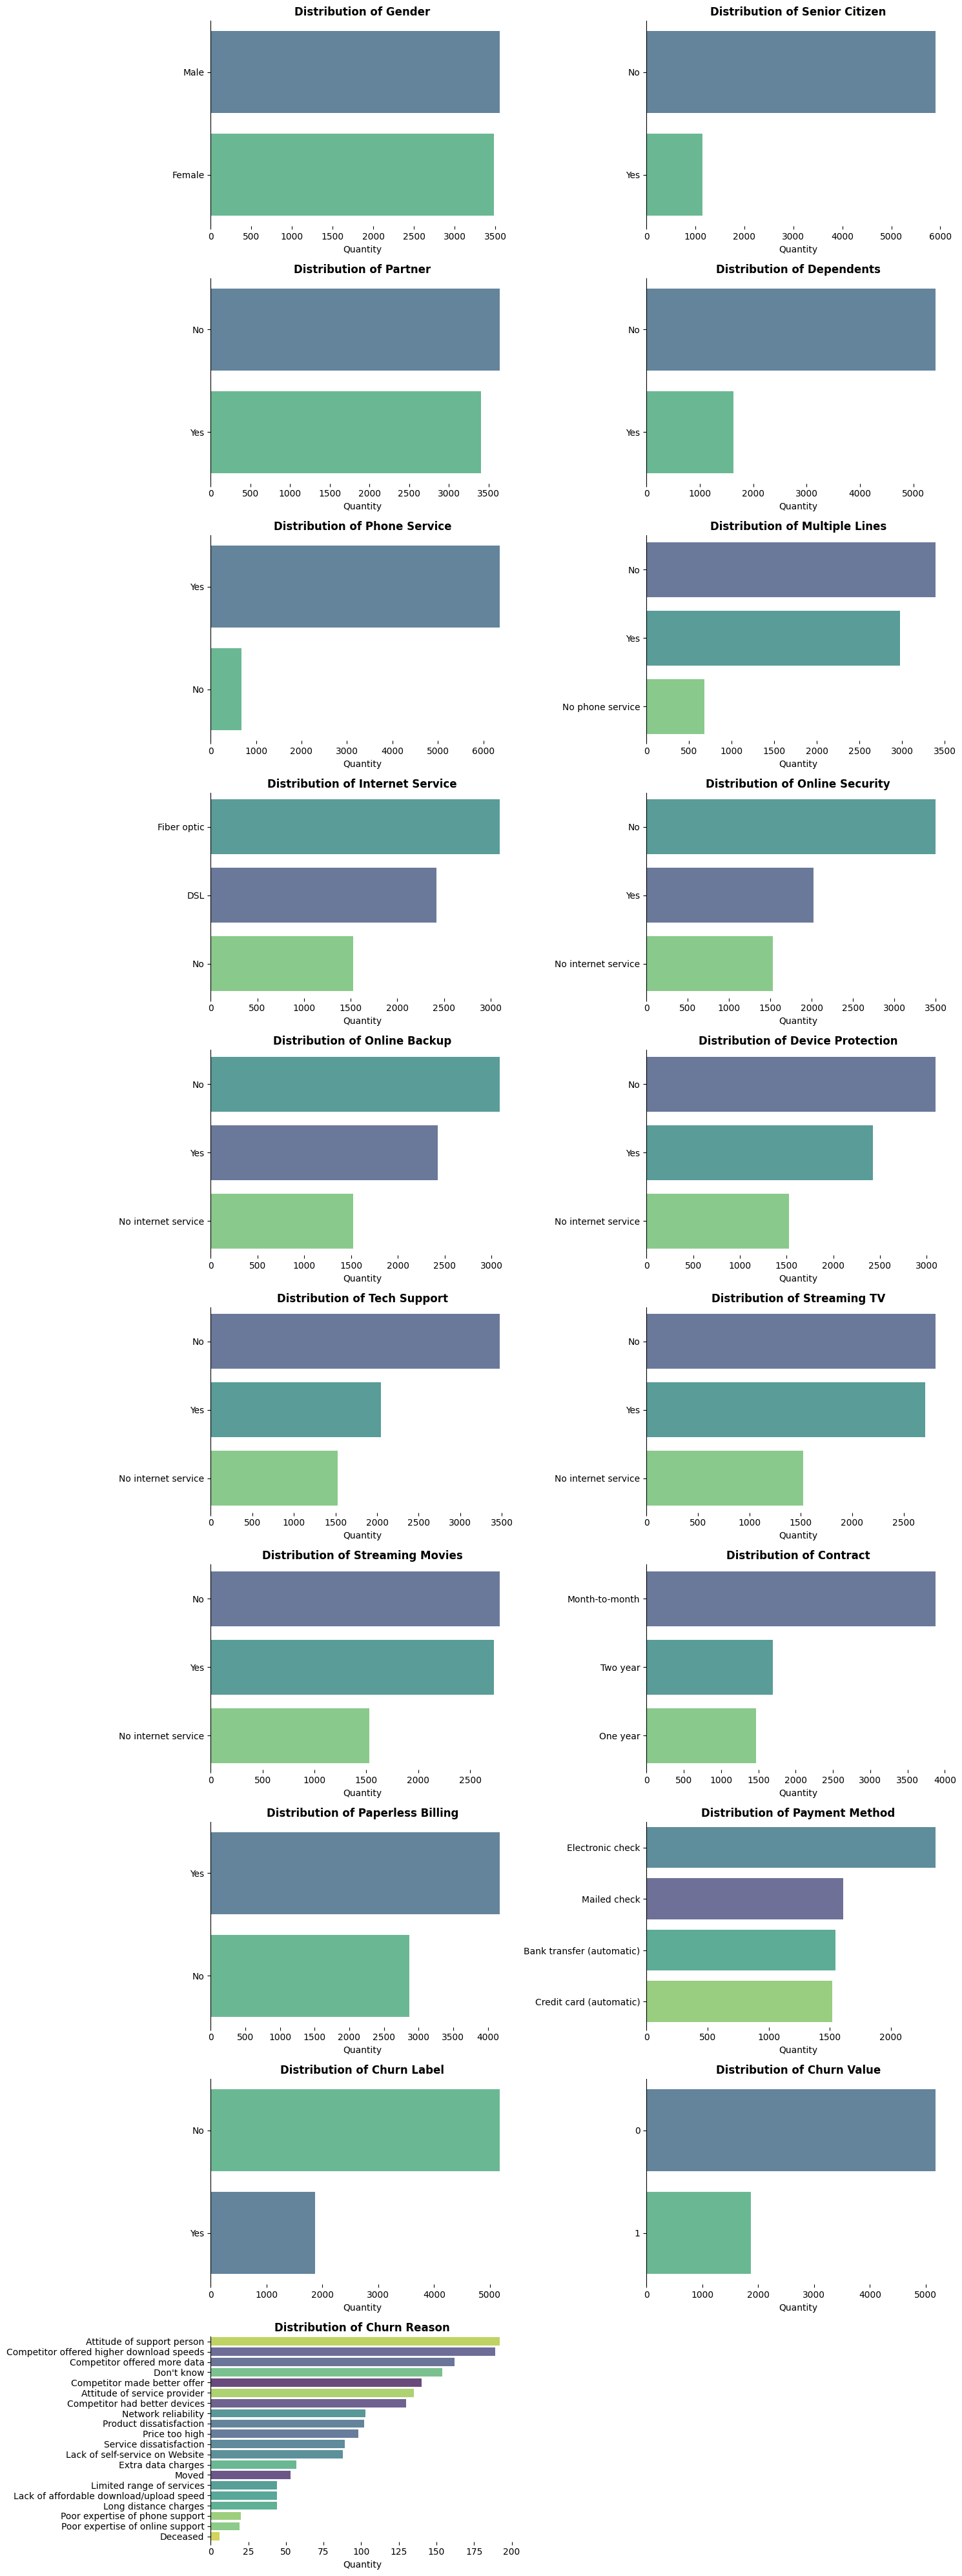

In [7]:
# @title Variables Distribution
categorical_variables = df_dict.query("type == 'Qualitative' and variable not in ['Country', 'State','City', 'Zip Code', 'Lat Long', 'CustomerID']").variable.to_list()

n_vars = len(categorical_variables)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(figsize=(15, n_rows * 4), ncols=n_cols, nrows=n_rows)
axes = axes.flatten()

for i, variable in enumerate(categorical_variables):
    order = df[variable].value_counts().index

    ax = sns.countplot(data=df, y=variable, ax=axes[i], order=order, palette="viridis", hue=variable, legend=False, alpha=.8)

    ax.set_title(f"Distribution of {variable}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Quantity")
    ax.set_ylabel("")

    for side in ["bottom", "top", "right"]:
        ax.spines[side].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

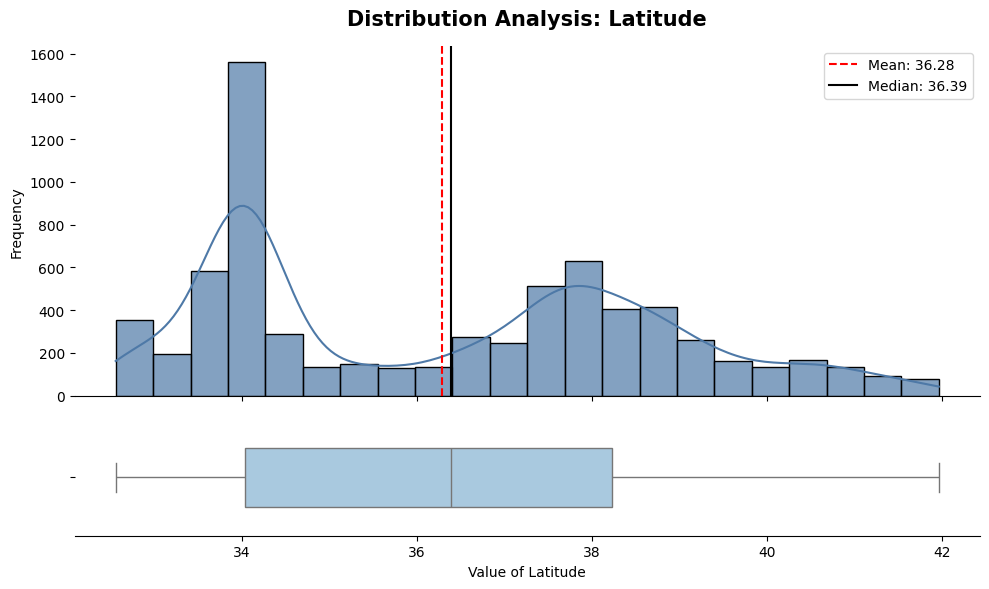

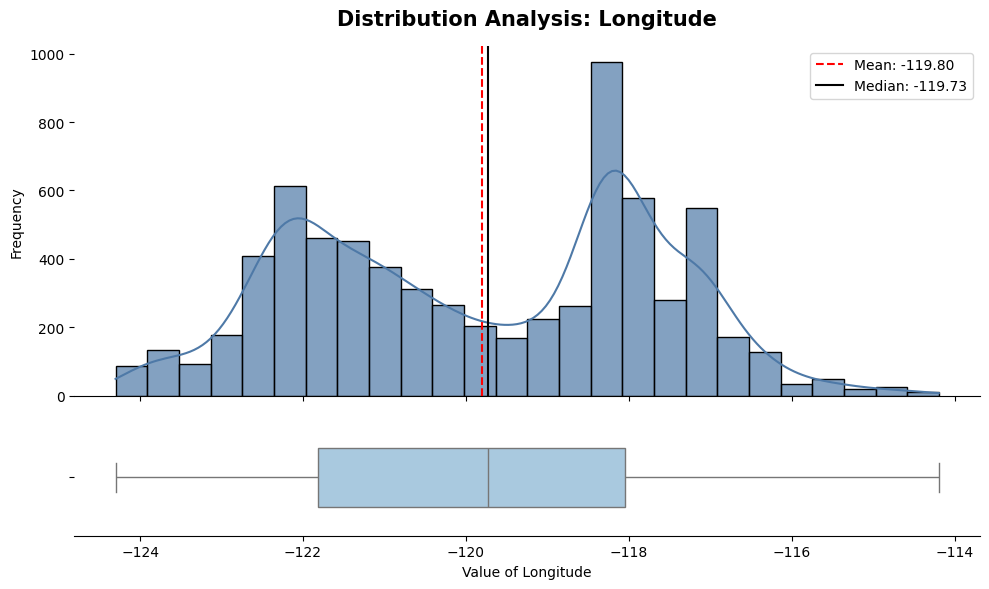

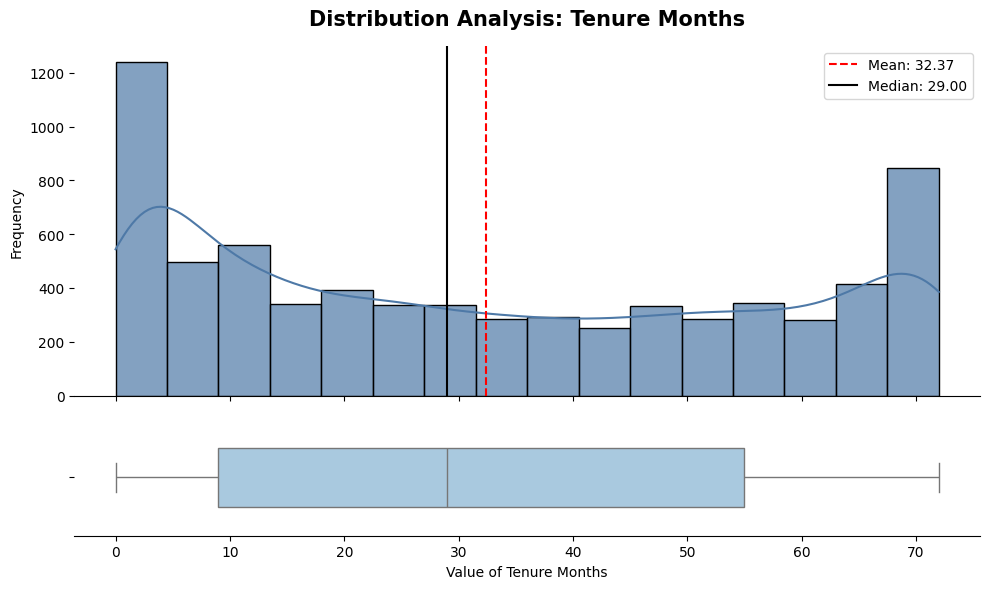

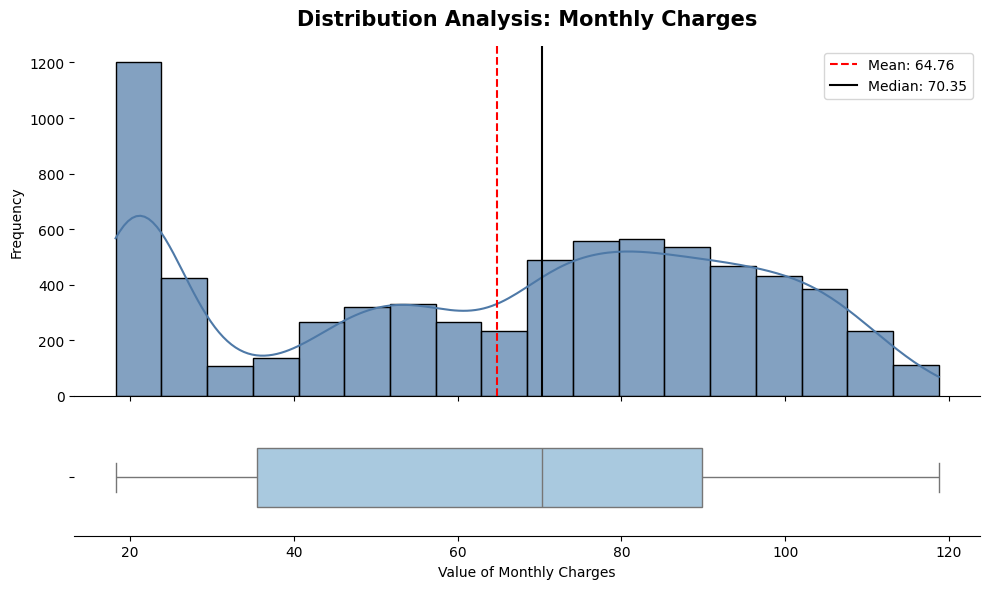

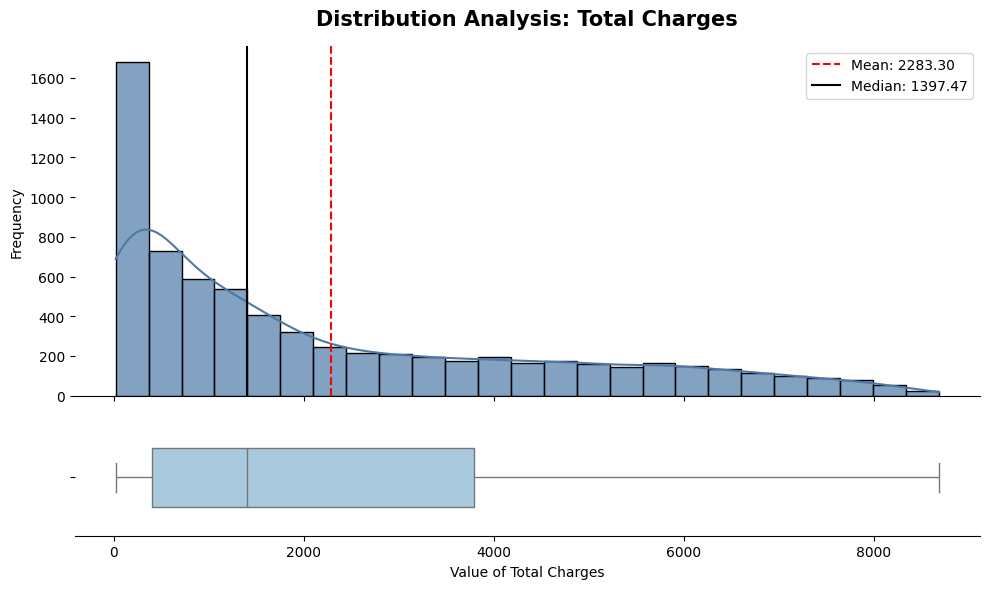

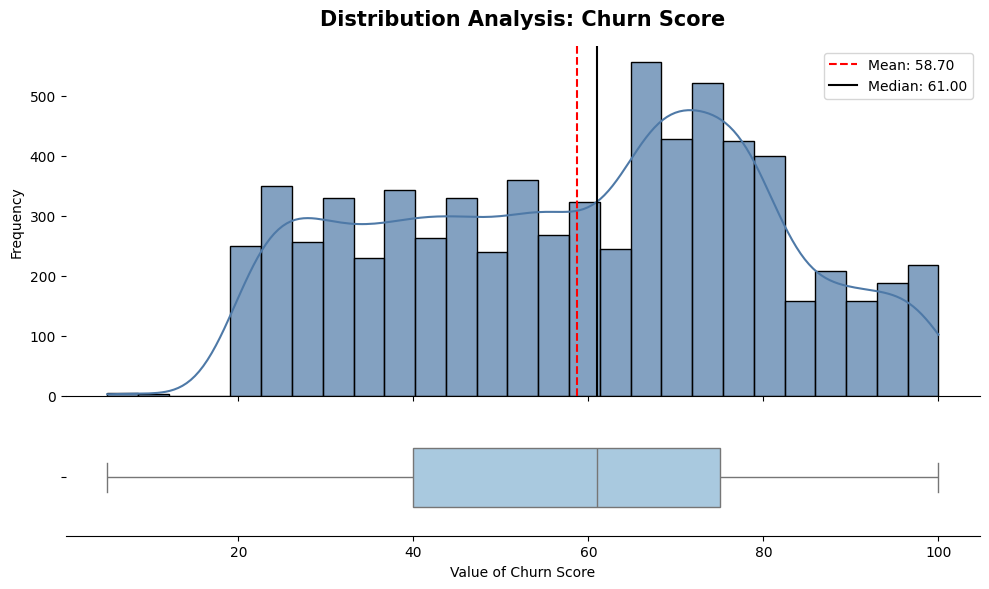

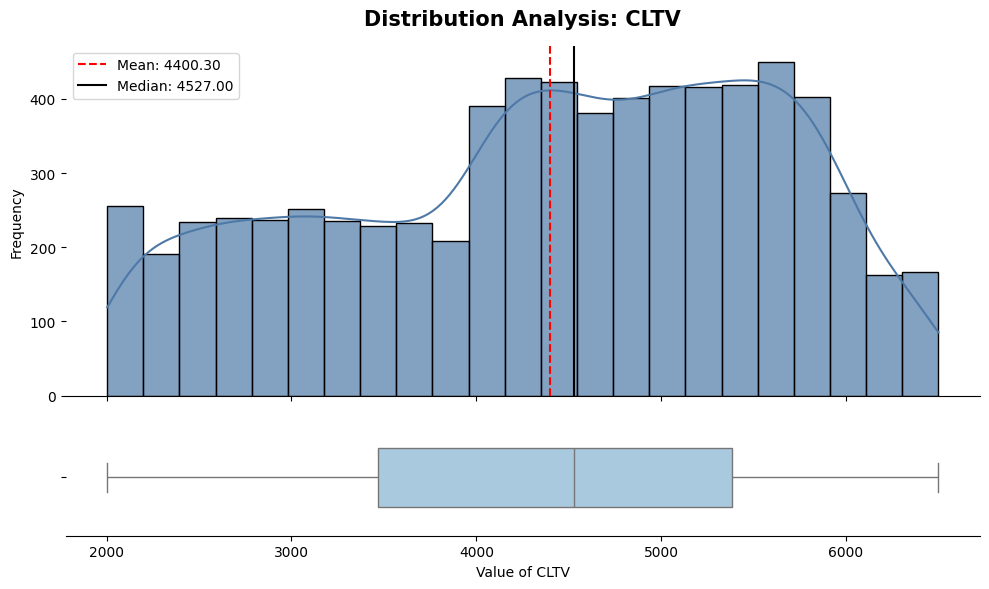

In [8]:
# @title Quantitative Variables Analysis

quantitative_vars = df_dict.query("type == 'Quantitative'").variable.to_list()

for var in quantitative_vars:

    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(10, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    sns.histplot(data=df, x=var, ax=ax_hist, kde=True, color="#4e79a7", alpha=.7)

    mean_val = df[var].mean()
    median_val = df[var].median()
    ax_hist.axvline(mean_val, color="red", linestyle="--", label=f"Mean: {mean_val:.2f}")
    ax_hist.axvline(median_val, color="black", linestyle="-", label=f"Median: {median_val:.2f}")

    ax_hist.set_title(f"Distribution Analysis: {var}", fontweight="bold", fontsize=15, pad=15)
    ax_hist.set_ylabel("Frequency")
    ax_hist.legend()

    sns.boxplot(data=df, x=var, ax=ax_box, color="#a0cbe8", width=0.5)
    ax_box.set_xlabel(f"Value of {var}")

    sns.despine(ax=ax_hist, left=True)
    sns.despine(ax=ax_box, left=True)

    plt.tight_layout()
    plt.show()

In [9]:
# @title Missing Data

df.isnull().sum()

CustomerID              0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

---

There's 5174 missing values on Churn Reason and 11 at Total Charges

---

## Bivariate Analysis

### Relationship between quantitative variables

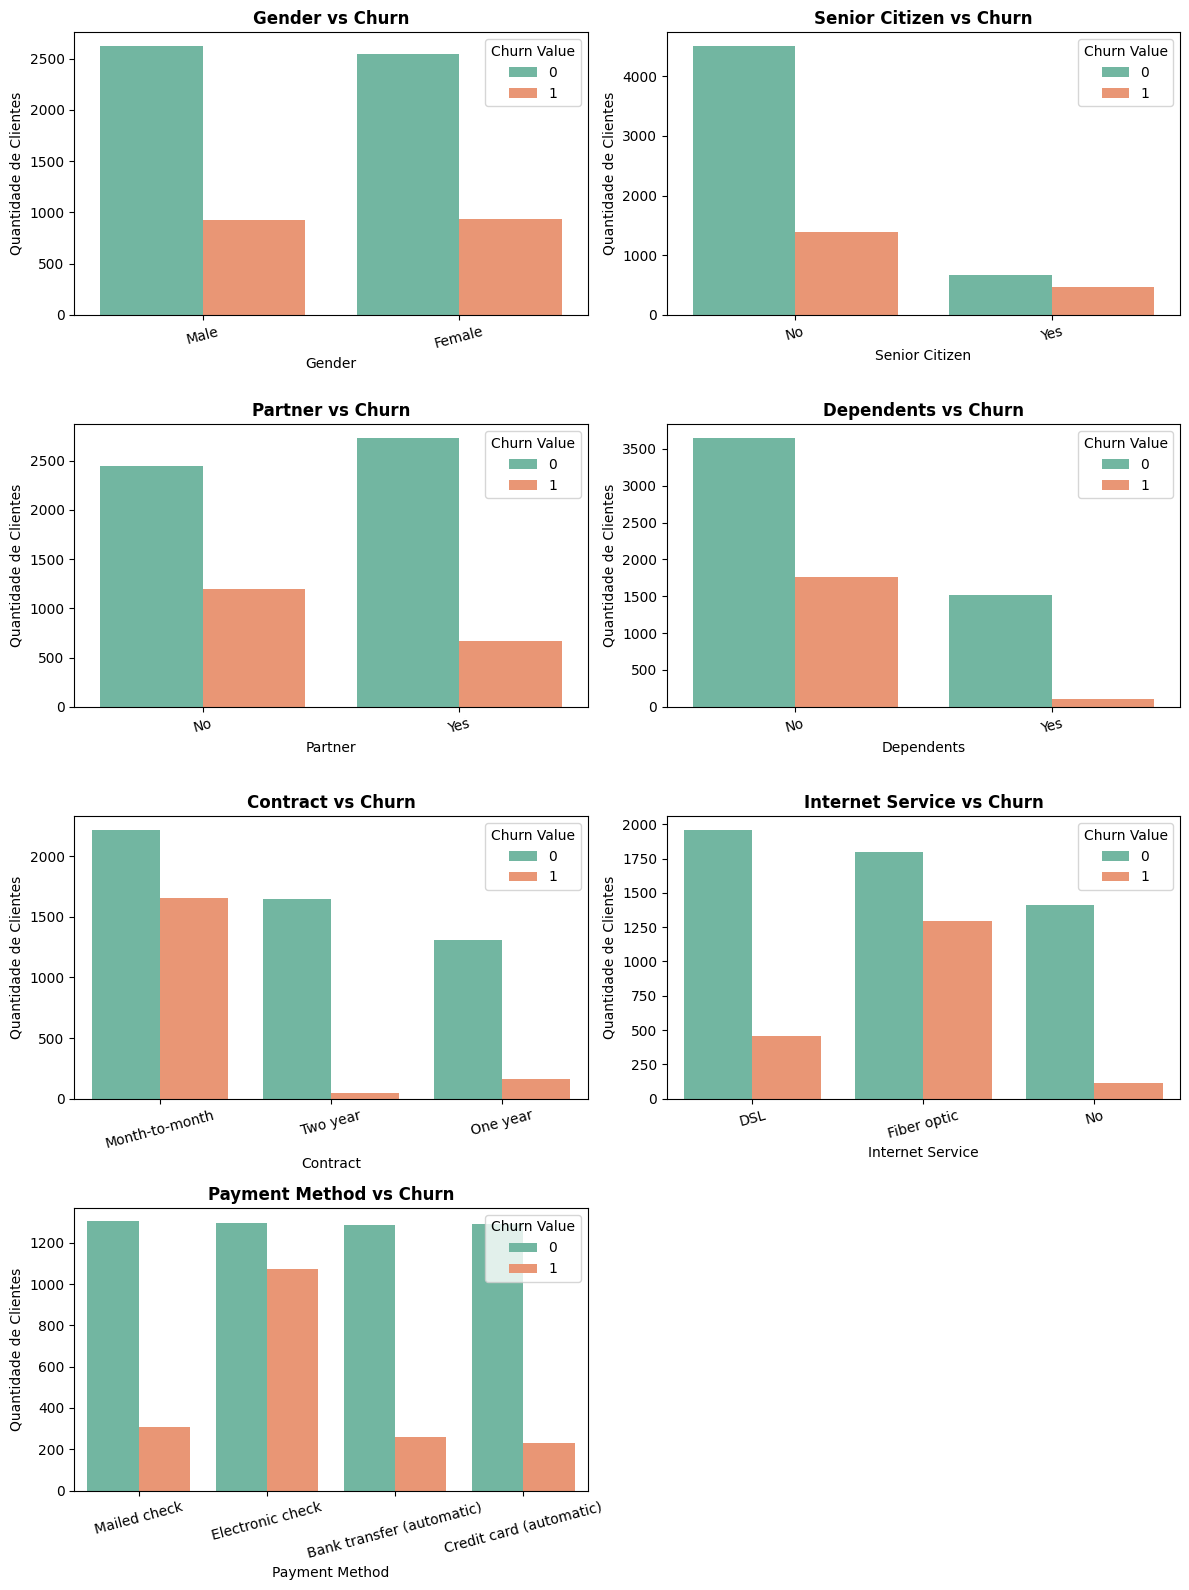

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Escolha as variáveis que você realmente quer investigar
# Excluí IDs, Lat/Long e numéricas contínuas dessa lista
categorical_vars = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Contract', 'Internet Service', 'Payment Method'
]

# Configurar o grid (ex: 2 colunas)
n_cols = 2
n_rows = math.ceil(len(categorical_vars) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

# Loop focado: Cada variável categórica contra o Churn Value
for i, var in enumerate(categorical_vars):
    sns.countplot(data=df, x=var, hue='Churn Value', ax=axes[i], palette='Set2')
    axes[i].set_title(f'{var} vs Churn', fontweight='bold')
    axes[i].set_ylabel('Quantidade de Clientes')

    # Rotacionar os textos do eixo X se forem muito grandes (ex: Payment Method)
    axes[i].tick_params(axis='x', rotation=15)

# Limpar os gráficos vazios que sobrarem no grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

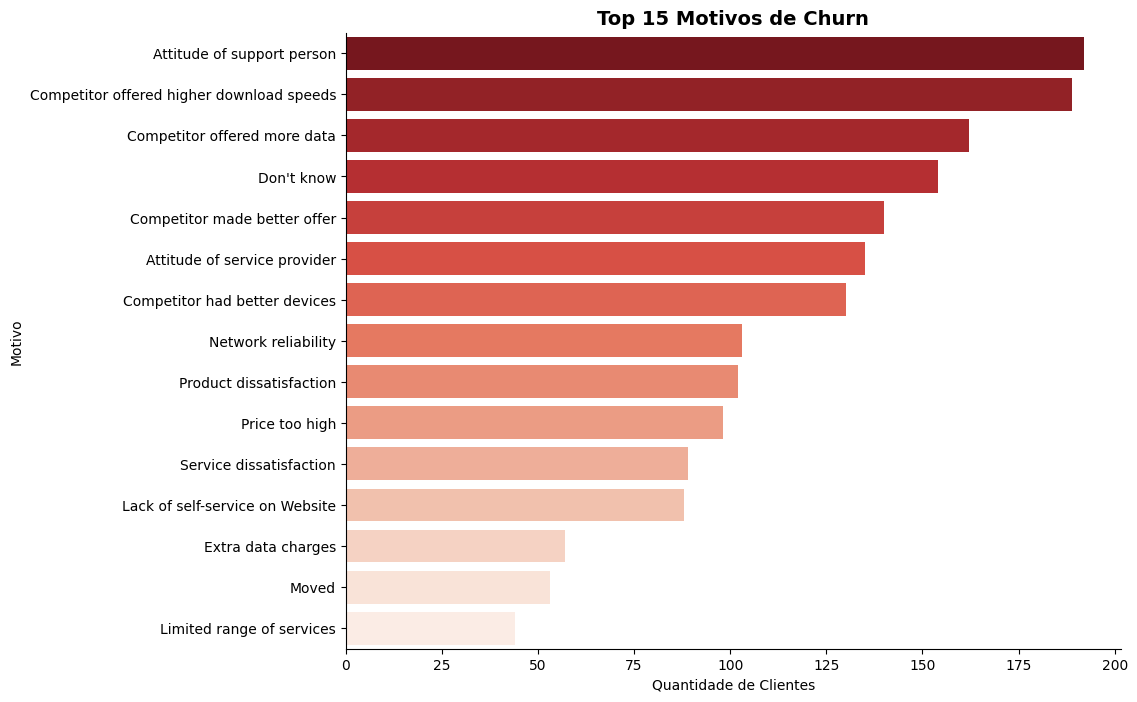

In [11]:
plt.figure(figsize=(10, 8))

# Filtra apenas quem tem um motivo de cancelamento preenchido
churn_reasons = df['Churn Reason'].dropna()

# Conta a frequência e pega os top 15 motivos para não poluir o gráfico
top_reasons = churn_reasons.value_counts().head(15)

sns.barplot(x=top_reasons.values, y=top_reasons.index, palette='Reds_r')

plt.title('Top 15 Motivos de Churn', fontweight='bold', fontsize=14)
plt.xlabel('Quantidade de Clientes')
plt.ylabel('Motivo')
sns.despine() # Remove as bordas feias do gráfico
plt.show()

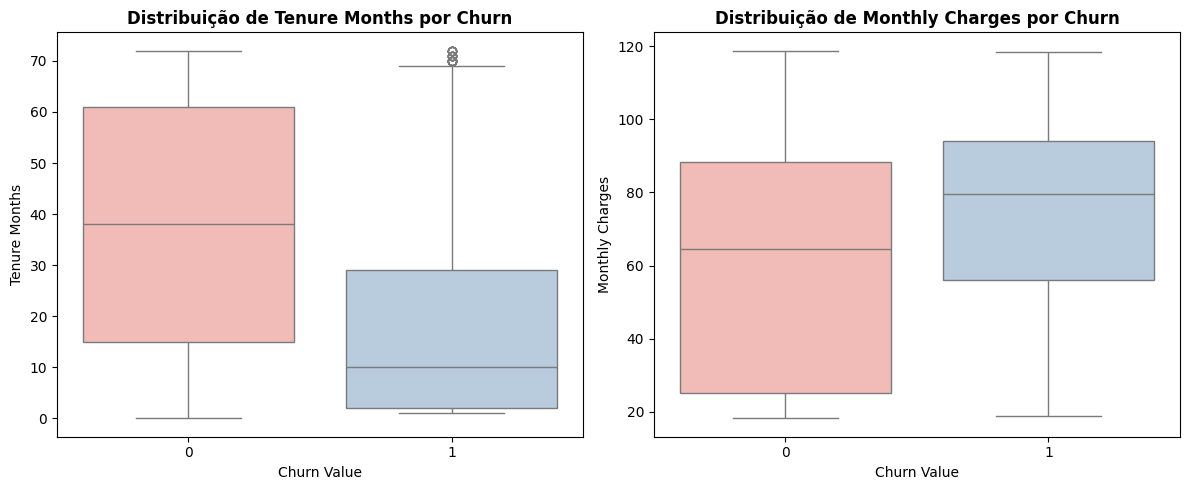

In [12]:
# Exemplo rápido para variáveis numéricas
numeric_vars = ['Tenure Months', 'Monthly Charges']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(numeric_vars):
    sns.boxplot(data=df, x='Churn Value', y=var, ax=axes[i], palette='Pastel1')
    axes[i].set_title(f'Distribuição de {var} por Churn', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Features selected after EDA
features = [
    'Tenure Months', 'Monthly Charges', 'Total Charges',
    'Contract', 'Internet Service', 'Payment Method',
    'Senior Citizen', 'Partner', 'Dependents'
]

df_model = df[features + ['Churn Value']].dropna()

# Encoding Categorical Variables
le = LabelEncoder()
cat_cols = ['Contract', 'Internet Service', 'Payment Method',
            'Senior Citizen', 'Partner', 'Dependents']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop('Churn Value', axis=1)
y = df_model['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Results\n")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

=== Resultados do Modelo ===

              precision    recall  f1-score   support

   Não Churn       0.83      0.87      0.85      1033
       Churn       0.58      0.51      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.76      0.77      0.77      1407



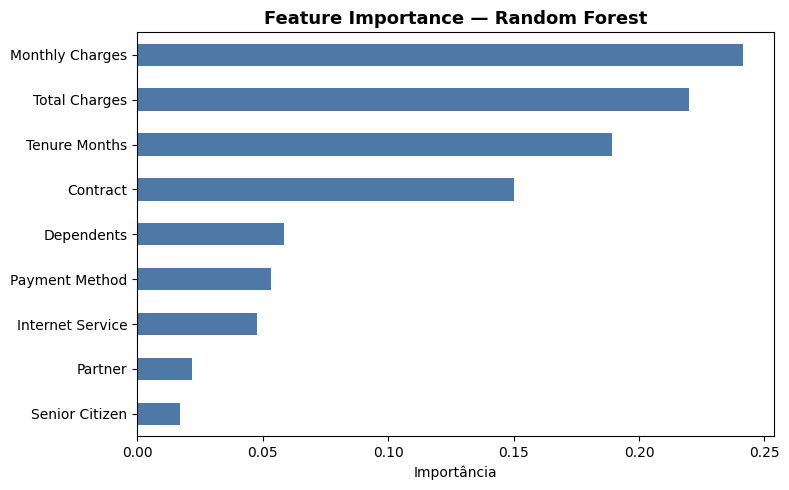

In [ ]:
feat_importance = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_importance.plot(kind='barh', ax=ax, color='#4e79a7')
ax.set_title('Feature Importance — Random Forest', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Conclusion

### What the model learnt
- **Tenure Months** & **Monthly Charges**  are the main reason of churn - new clients paying expensive plans have more risk of churn.
- Contract **Month-to-Month** have a higher tax of churn way more than annual or biannual.
- **Total Charges** low + **Tenure** short = alert

### Desempenho
- The model reach ~80% of accuracy with RandomForest balanced
- Recall for class Churn is more important in this context of business — it's preferably miss identifying a client as churn rather than losing who will cancel.

### Próximos passos possíveis
- Test XGBoost and compare metrics
- Build an API with FastAPI that receives data of a client and return a probability of churn
- Pipeline and retraing automatic with Apache Airflow

# Analysis — Telecommunications

Análise exploratória e modelo preditivo de churn em base de clientes de uma empresa de telecomunicações.

## Problema
Churn (cancelamento de clientes) é uma das métricas mais críticas para empresas de telecom. Este projeto identifica os principais fatores associados ao cancelamento e treina um modelo capaz de prever quais clientes têm maior risco.

## Dataset
- **Fonte**: IBM Telco Customer Churn Dataset
- **Volume**: 7.043 clientes, 33 variáveis
- **Target**: `Churn Value` (0 = ficou, 1 = cancelou)

## Estrutura
```
├── data/
│   └── Telco_customer_churn.xlsx
├── notebooks/
│   └── 01-eda & model.ipynb
└── README.md
```

## Principais achados
- Clientes com contratos mensais têm 3x mais churn que anuais
- Os primeiros 12 meses são o período crítico de retenção
- Monthly Charges acima de $65 combinado com contrato mensal = maior risco

## Tecnologias
Python · Pandas · Matplotlib · Seaborn · Scikit-learn